In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    log_loss,
    brier_score_loss
)
import matplotlib.pyplot as plt
import seaborn as sns

#Load the dataset
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

#Features
X = [
    "rank_diff",
    "rank_points_diff",
    "elo_diff",
    "age_diff",
    "selo_diff",
    "comp_diff",
    "serv_diff",
    "form_diff",
]


#Target
y = "result"

#Empty storage lists
dates = []
predictions = []
actuals = []
probabilities = []
best_params_list = []
cv_monitor = []
row_ids = []

#Rolling setup
WINDOW_SIZE = 10000 
STEP = 100

#RF model
RF = RandomForestClassifier(
    random_state=1,
    n_jobs=-1
)

#Hyperparameter grid
param_grid = {
    "n_estimators": [150, 200],
    "max_depth": [6, 8],
    "min_samples_leaf": [5, 10],
    "max_features": [3, None],
}

#Rolling window forecast loop
for i in range(WINDOW_SIZE, len(df), STEP):
    train_data = df.iloc[i-WINDOW_SIZE:i]
    test_data = df.iloc[i:i+STEP]

    if len(test_data) == 0:
        break

    X_train = train_data[X]
    y_train = train_data[y]
    X_test = test_data[X]
    y_test = test_data[y]

    tscv = TimeSeriesSplit(n_splits=2)

    search = GridSearchCV(
        estimator=RF,
        param_grid=param_grid,
        cv=tscv,
        n_jobs=-1,
        scoring="neg_log_loss",
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)

    #CV monitoring
    res = pd.DataFrame(search.cv_results_)
    best_row = res.iloc[search.best_index_]

    cv_monitor.append({
        "Index": i,
        "Date": test_data["tourney_date"].iloc[0],
        "Best_Params": search.best_params_,
        "Mean_Train_Score": float(best_row["mean_train_score"]),
        "Mean_Valid_Score": float(best_row["mean_test_score"]),
    })

    #Store predictions
    best_params_list.append(search.best_params_)
    dates.extend(test_data["tourney_date"].tolist())

    preds = search.predict(X_test)
    probs = search.predict_proba(X_test)[:, 1]

    predictions.extend(preds)
    probabilities.extend(probs)
    actuals.extend(y_test.tolist())
    row_ids.extend(test_data.index.tolist())

/Users/arttusokka/Documents/AThesis/Predicting-ATP-matches-outcome/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/arttusokka/Documents/AThesis/Predicting-ATP-matches-outcome/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/arttusokka/Documents/AThesis/Predicting-ATP-matches-outcome/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn

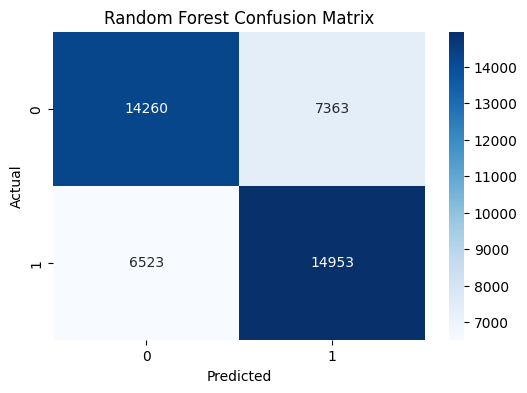

Accuracy: 0.678
Log Loss: 0.593
Brier Score: 0.204


In [ ]:
#Confusion matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.savefig("rf_confusion_matrix.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

#Accuracy
accuracy = accuracy_score(actuals, predictions)
print(f"Accuracy: {accuracy:.3f}")

#Log loss
logloss = log_loss(actuals, probabilities)
print(f"Log Loss: {logloss:.3f}")

#Brier score
brier_score = brier_score_loss(actuals, probabilities)
print(f"Brier Score: {brier_score:.3f}")

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

# Load the dataset
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

# Features
X = [
    "rank_diff",
    "rank_points_diff",
    "elo_diff",
    "age_diff",
    "selo_diff",
    "comp_diff",
    "serv_diff",
    "form_diff",
]

# Target
y = "result"

# Rolling setup
WINDOW_SIZE = 10000
STEP = 100

# Storage for feature importances from each rolling window
rf_importances = []

# Refit random forest in each rolling window using already selected best params
for k, i in enumerate(range(WINDOW_SIZE, len(df), STEP)):

    # Stop if best_params_list does not contain more saved parameter sets
    if k >= len(best_params_list):
        break

    train_data = df.iloc[i-WINDOW_SIZE:i]
    test_data = df.iloc[i:i+STEP]

    if len(test_data) == 0:
        break

    X_train = train_data[X]
    y_train = train_data[y]

    # Use best hyperparameters selected earlier by GridSearchCV
    rf_model = RandomForestClassifier(
        random_state=1,
        n_jobs=-1,
        **best_params_list[k]
    )

    rf_model.fit(X_train, y_train)

    # Store impurity-based feature importances
    rf_importances.append(rf_model.feature_importances_)

# Convert to array
rf_importances = np.array(rf_importances)

# Average feature importance across all rolling windows
avg_rf_importance = rf_importances.mean(axis=0)

# Create dataframe
feature_importance_rf = pd.DataFrame({
    "Feature": X,
    "Importance": avg_rf_importance
})

# Preserve feature order
feature_importance_rf["Feature"] = pd.Categorical(
    feature_importance_rf["Feature"],
    categories=X,
    ordered=True
)

feature_importance_rf = feature_importance_rf.sort_values("Feature")

# Plot
plt.figure(figsize=(6, 4))

plt.bar(
    feature_importance_rf["Feature"],
    feature_importance_rf["Importance"],
    width=0.6
)

plt.title("Average Random Forest Impurity Decrease")
plt.ylabel("Impurity decrease")
plt.xticks(rotation=45, ha="right")

plt.margins(x=0.01)
plt.tight_layout()

# Save as PDF
plt.savefig("../figures/rf_impurity_decrease.pdf", bbox_inches="tight")

plt.show()

# Show values
feature_importance_rf

NameError: name 'rf_model' is not defined

In [ ]:
from collections import Counter
import pandas as pd

all_params = {}
total = len(best_params_list)

for d in best_params_list:
    for key, value in d.items():
        if key not in all_params:
            all_params[key] = []
        all_params[key].append(value)

result = []
for param, values in all_params.items():
    counts = Counter(values)
    for val, count in counts.items():
        result.append({
            "Parameter": param,
            "Value": val,
            "Percentage": round(count / total * 100, 1)
        })

df_params = pd.DataFrame(result).sort_values(["Parameter", "Value"])
print(df_params)

          Parameter  Value  Percentage
0         max_depth      6        98.6
1         max_depth      8         1.4
2      max_features      3       100.0
4  min_samples_leaf      5        26.7
3  min_samples_leaf     10        73.3
6      n_estimators    150        37.1
5      n_estimators    200        62.9


In [ ]:
#ranking group analysis
oos_rf = df.loc[row_ids, ["player1_rank", "player2_rank"]].copy()

oos_rf["actual"] = actuals
oos_rf["pred_rf"] = predictions
oos_rf["prob_rf"] = probabilities


# Ranking group analysis
bins = [0, 3, 10, 25, 50, 100, 2000]

labels = [
    "Rank 1-3",
    "Rank 4-10",
    "Rank 11-25",
    "Rank 26-50",
    "Rank 51-100",
    "Rank 101-2000",
]

oos_rf["rank_group"] = pd.cut(
    oos_rf["player1_rank"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

rank_results_rf = (
    oos_rf
    .groupby("rank_group", observed=True)
    .apply(lambda g: pd.Series({
        "n": len(g),
        "Random forest accuracy": accuracy_score(g["actual"], g["pred_rf"]),
    }))
    .reset_index()
)

print("\nRanking group results:")
print(rank_results_rf.round(3).to_string(index=False))


Ranking group results:
   rank_group       n  Random forest accuracy
     Rank 1-3  1710.0                   0.839
    Rank 4-10  3403.0                   0.751
   Rank 11-25  6311.0                   0.680
   Rank 26-50  9484.0                   0.656
  Rank 51-100 13342.0                   0.656
Rank 101-2000  8849.0                   0.673


In [ ]:
#Create out-of-sample prediction dataframe for random forest
oos_rf = df.loc[row_ids, ["tourney_date", "rank_diff"]].copy()

oos_rf["actual"] = actuals
oos_rf["pred_rf"] = predictions
oos_rf["prob_rf"] = probabilities

# Rank difference group analysis
bins = [0, 10, 25, 50, 100, 250, np.inf]

labels = [
    "0-10",
    "11-25",
    "26-50",
    "51-100",
    "101-250",
    "251+",
]

oos_rf["rank_diff_abs"] = oos_rf["rank_diff"].abs()

oos_rf["Absolute ranking difference"] = pd.cut(
    oos_rf["rank_diff_abs"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

rank_diff_results_rf = (
    oos_rf
    .groupby("Absolute ranking difference", observed=True)
    .apply(lambda g: pd.Series({
        "Observations": len(g),
        "Random Forest": accuracy_score(g["actual"], g["pred_rf"]),
    }))
    .reset_index()
)

rank_diff_results_rf["Observations"] = rank_diff_results_rf["Observations"].astype(int)

print("\nRank difference group results:")
print(rank_diff_results_rf.round(3).to_string(index=False))


Rank difference group results:
Absolute ranking difference  Observations  Random Forest
                       0-10          6344          0.605
                      11-25          8336          0.626
                      26-50         10774          0.668
                     51-100         10162          0.721
                    101-250          5611          0.743
                       251+          1872          0.772
